# CATS AND DOGS

In the proccess of this project we will discuss the quality of various Neural Network models to analyse and Classify a Dataset of 37 types of cat and dog races. This short study will be done using a Dataset provided by Oxford University called : Oxford-IIIT Pet Dataset. 

The project is divided in 5 different steps :

- Exploration of the Dataset
- Binary Classification between cats and dogs
- Classification between 37 cat and dog races
- Animal Segmentation
- Comparative Analyses

In [1]:
%load_ext autoreload
%autoreload 2

import random

import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


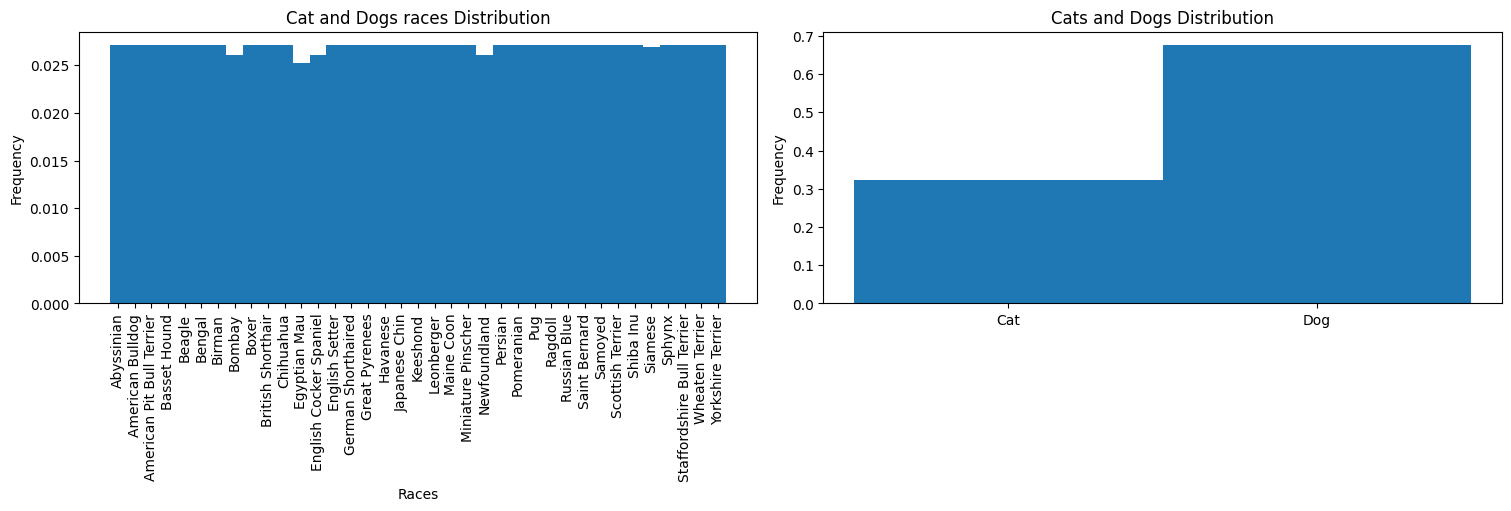

In [2]:
datapath = '../data/data_cats_and_dogs'
transform = torchvision.transforms.ToTensor()
dataset = torchvision.datasets.OxfordIIITPet(root=datapath, target_types="binary-category", download=True, transform=transform)

def get_data_statistics(dataset):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), layout="constrained")

    axes[0].hist(dataset._labels, bins=np.arange(38)-0.5, density=True)
    axes[0].set_title('Cat and Dogs races Distribution')
    axes[0].set_xlabel('Races')
    axes[0].set_xticks(np.arange(37))
    axes[0].set_xticklabels(list(dataset.classes))
    axes[0].set_ylabel('Frequency')
    axes[0].tick_params(axis='x', rotation=90)
    
    axes[1].hist(dataset._bin_labels, bins=np.arange(3)-0.5, density=True)
    axes[1].set_title('Cats and Dogs Distribution')
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(list(dataset.bin_classes))
    axes[1].set_ylabel('Frequency')
    plt.show()

get_data_statistics(dataset)

Il y a nettement plus d'images de chiens que de chats</p>
Les 37 races sont globalement équilibrées

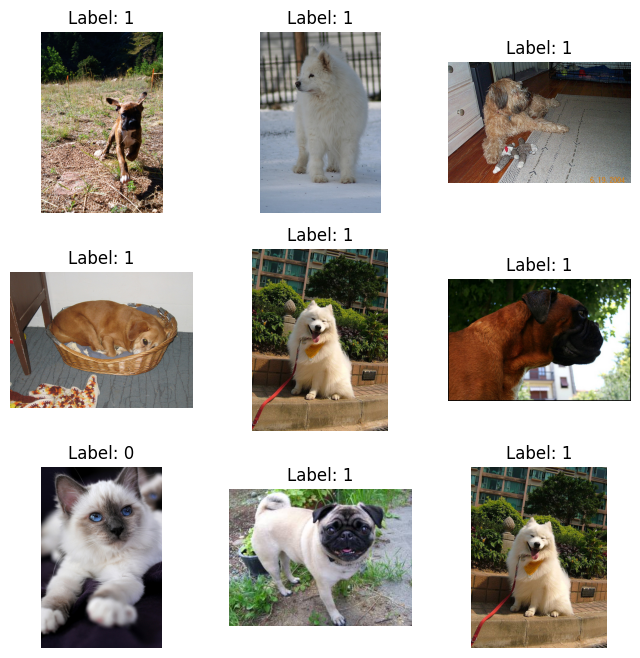

In [3]:
# fonction à insérer dans utils
# Plot 9 random images from the MNIST train dataset
def plot_images(img_dataset, RGB='True'):
    """Plots 9 random images from the given dataset

    Args:
        img_dataset (torch.utils.data.Dataset): The dataset to plot images from
    """
    # Set up a 3x3 grid for plotting 9 random images
    figure = plt.figure(figsize=(8, 8))
    cols, rows = 3, 3
    
    # Plot 9 random images from the img_dataset
    for i in range(1, cols * rows + 1):
        random_idx = torch.randint(len(img_dataset), size=(1,)).item()  # Pick a random index
        img, label = img_dataset[random_idx]  # Get the image and its label
        figure.add_subplot(rows, cols, i)  # Add subplot
        plt.title(f'Label: {label}')  # Set title to show the label
        plt.axis("off")  # Turn off axis
        if RGB == 'True':
            plt.imshow(torch.permute(img.squeeze(),(1,2,0)))  # Plot image
        else:
            plt.imshow(img.squeeze())  # Plot image
    
    plt.show()  # Display the figure

plot_images(dataset)

Biais visuels possibles :</p>
Animaux parfois entiers, parfois coupés, luminosité parfois mauvaise, la résolution est bonne mais nous devrons probablement la dégrader pour pouvoir entrainer un CNN. La taille des images devra être modifiée pour qu'elles aient toutes les mêmes dimensions

In [5]:
dataset

Dataset OxfordIIITPet
    Number of datapoints: 3680
    Root location: ../data/data_cats_and_dogs
    StandardTransform
Transform: ToTensor()

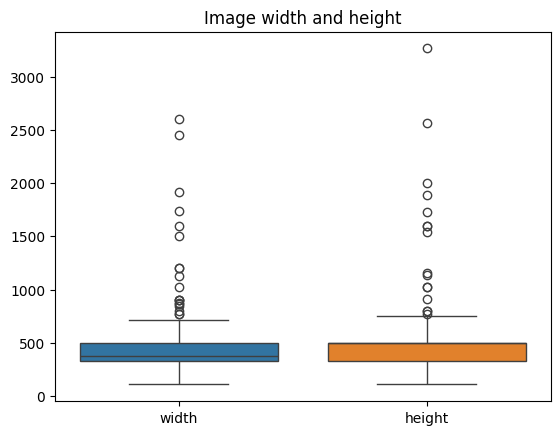

In [7]:
# Boxplots shapes of the images:

img_sizes = []
for i in range(3680):
    img, _ = dataset[i]
    img_sizes.append([np.shape(img)[1], np.shape(img)[2]])

import seaborn as sns
plt.figure()
ax = sns.boxplot(np.array(img_sizes))
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(['width', 'height'])
plt.title("Image width and height")
plt.show()

In [9]:
print(f'mean width: {int(np.mean(img_sizes))}, mean height: {int(np.mean(img_sizes))}')

mean width: 407, mean height: 407


#### Reshapping images to the mean shape

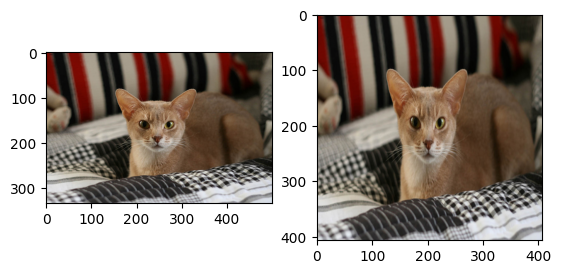

In [3]:
# test sur une image

from torchvision.transforms import Resize, ToTensor, InterpolationMode
import torch.nn.functional as F

resizing = Resize((407, 407))
img, _ = dataset[25]
img_new = resizing(img)
fig, axs = plt.subplots(1,2)
axs[0].imshow(torch.permute(img.squeeze(),(1,2,0)))
axs[1].imshow(torch.permute(img_new.squeeze(),(1,2,0)))

The mean value may be to high to train the model efficiently, it will probably be choosen lowaer than 407 at the end to train the model

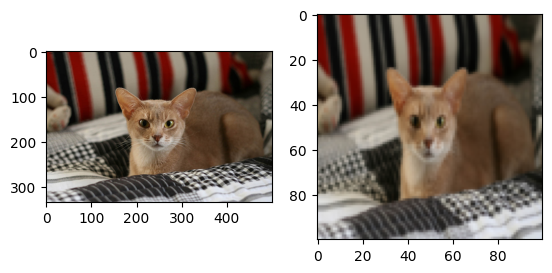

In [11]:
resizing = Resize((100, 100))
img, _ = dataset[25]
img_new = resizing(img)
fig, axs = plt.subplots(1,2)
axs[0].imshow(torch.permute(img.squeeze(),(1,2,0)))
axs[1].imshow(torch.permute(img_new.squeeze(),(1,2,0)))

In [3]:
## FONCTION IMPORTATION DES DONNEES choix de la taille des images, de la taille du batch et de la catégorie (espèce, race ou segmentation)

def get_datasets_loaders(batch_size, target_types:str="binary-category", size=(100, 100), norm_like_VGG16=False):
    """_gets datasets and dataloaders for the OxfordIIIPet dataset depending on the targeted labels or segmentation_

    Args:
        batch_size (int): batch size
        target_types (str): _
            "binary-category" : cats / dogs, 
            "category" : cats and dogs races, 
            "segmentation" : PIL image segmentation trimap of the images
        resize (bool): resize the images
        size (tuple): resize the images with this size_.
    """
    transform = torchvision.transforms.Compose([torchvision.transforms.Resize(size),
                                                    torchvision.transforms.ToTensor()])
    if norm_like_VGG16 == True:
        transform = torchvision.transforms.Compose([torchvision.transforms.Resize(size),
                                                    torchvision.transforms.ToTensor(),
                                                    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]) # recommended for VGG16 cf Doc
    
    train_dataset = datasets.OxfordIIITPet(root=datapath, split="trainval", target_types=target_types, transform=transform, download=True) #transform=transform,
    test_dataset = datasets.OxfordIIITPet(root=datapath, split="test", target_types=target_types, transform=transform, download=True) #transform=transform

    train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

    return train_dataset, test_dataset, train_loader, test_loader

<p>IMPORTANT NOTE : the transform argument enables to influence the entry (the image to recognize), it transforms it into a tensor, when the resize argument is True, before converting the image into a tensor, the torchvision function Resize() is applied to the image, so this function is composed with the torchvision function <b>ToTensor()</b>. Removing the composition and keeping only the <b>Resize()</b> function will return a dataset with PIL.Images as entries. The choice of the "target_types" enables to choose between a binary category classification (cats and dogs), a race classification or a segmentation. However using keys such as 'classes' or 'bin_classes' unables to access the different classifications even if one was choosen as a target_types.</p>

In [5]:
batch_size = 20 

img_width, img_height = 407, 407 # may be choosen smaller for training efficiency
size = (img_width, img_height)

In [ ]:
train_dataset, test_dataset, train_loader, test_loader = get_datasets_loaders(batch_size, target_types="binary-category", resize=True, size=size)

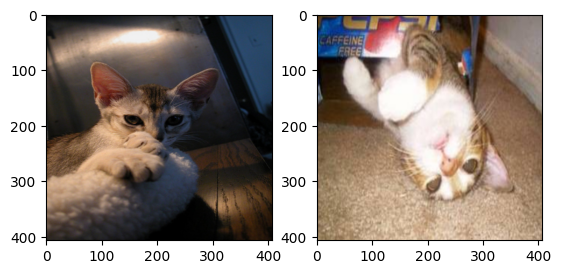

In [24]:
# test pour savoir si on a bien des ensembles différents pour le train et le test
img_train, _ = train_dataset[10]
img_test, _ = test_dataset[10]
fig, axs = plt.subplots(1,2)
axs[0].imshow(torch.permute(img_train.squeeze(),(1,2,0)))
axs[1].imshow(torch.permute(img_test.squeeze(),(1,2,0)))

### Part 1 : Classification - Fine-tuning de VGG16
<p> On utilise VGG16 comme base de convolution, ensuite on crée une tête classifiante binaire et on évalue les performance por différents batch_siez / taille des images / (facultatif) augmentation de données </p>

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

In [ ]:
num_classes = 1 # binary classification cats / dogs
batch_size = 60
num_epochs = 10 
learning_rate = 0.001
img_width, img_height = 224, 224 # recommandé pour VGG16, taille de IMAGENET dataset ayant entrainé vgg16
size = (img_width, img_height)

In [39]:
train_dataset, test_dataset, train_loader, test_loader = get_datasets_loaders(batch_size, target_types="binary-category", size=size, norm_like_VGG16=True)

In [22]:
model = models.vgg16(pretrained=True)
#model = models.vgg16_bn(pretrained=True).features

In [23]:
# base de convolution
model.features
# tête classifiante
model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [24]:
for param in model.features.parameters():
 param.requires_grad = False

In [ ]:
# modification de la dernière couche pour l'adapter au nombre de classes
model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# Fine-tuning loop for classification
def fine_tune_vgg16_binary(model, train_loader, test_loader, epochs=5):
    model = model.to(device)
    optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss() # car on ne fait pas de sigmoid dans le modèle

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images = images.to(device)
            labels= labels.float()
            labels = labels.to(device)
            optimizer.zero_grad()
            output = model(images)
            output = output.view(-1)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader)}")

In [ ]:
fine_tune_vgg16_binary(model, train_loader, test_loader, epochs=5)

Epoch 1/5, Loss: 0.8157317653724199
Epoch 2/5, Loss: 0.7521536422556111
Epoch 2/5, Loss: 0.7521536422556111
Epoch 3/5, Loss: 0.6110414578028225
Epoch 3/5, Loss: 0.6110414578028225
Epoch 4/5, Loss: 1.0312929469384913
Epoch 4/5, Loss: 1.0312929469384913
Epoch 5/5, Loss: 1.5214911188191762
Epoch 5/5, Loss: 1.5214911188191762


In [ ]:
# Correction fine-tuning VGG16 pour classification binaire (chats vs chiens)
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

def fine_tune_vgg16_binary(train_loader, test_loader, epochs=5, lr=1e-3, device='cuda'):
    # Charger le modèle VGG16 pré-entraîné
    model = models.vgg16(pretrained=True)
    # Remplacer la dernière couche par une sortie binaire
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, 1)
    model = model.to(device)
    # Geler les couches convolutionnelles
    for param in model.features.parameters():
        param.requires_grad = False
    optimizer = optim.Adam(model.classifier.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss() # car on ne fait pas de sigmoid dans le modèle
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().to(device)  # labels binaires (0.0 ou 1.0)
            optimizer.zero_grad()
            outputs = model(images).view(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")
    return model

# Exemple d'appel (adapte device si besoin)
model_fine_tunned = fine_tune_vgg16_binary(train_loader, test_loader, epochs=5, lr=1e-4, device=device)


In [ ]:
# Correction fine-tuning VGG16 pour classification binaire (chats vs chiens)
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

def fine_tune_vgg16_binary(train_loader, test_loader, epochs=5, lr=1e-3, device='cuda'):
    # Charger le modèle VGG16 pré-entraîné
    model = models.vgg16(pretrained=True)
    # Remplacer la dernière couche par une sortie binaire
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, 1)
    model = model.to(device)
    # Geler les couches convolutionnelles
    for param in model.features.parameters():
        param.requires_grad = False
    optimizer = optim.Adam(model.classifier.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss() # car on ne fait pas de sigmoid dans le modèle
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        total_loss = 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().to(device)  # labels binaires (0.0 ou 1.0)
            optimizer.zero_grad()
            outputs = model(images).view(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            
            # Compute the test loss and accuracy
            predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        avg_loss = running_loss / len(train_loader)
        accuracy = 100 * correct / total
        model.eval()
        train_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for features, labels in test_loader:
                features = features.to(device)
                labels = labels.to(device)
                outputs = model(features).view(-1)
                loss = criterion(outputs, labels)
                train_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            test_loss = train_loss / len(test_loader)
            test_accuracy = 100 * correct / total

        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")
    return model

# Exemple d'appel (adapte device si besoin)
model_fine_tuned = fine_tune_vgg16_binary(train_loader, test_loader, epochs=5, lr=1e-4, device=device)


### Part 2 : Classification - Fine-tuning de VGG16 réutilisé
 <p> On récupère VGG16 fine-tuned sur notre jeu de données et on change la tête pour faire une classification en 36 catégories (softmax)

### Part 3: U-net from scratch pour Segmenter nos images